In [28]:
# ============================================================
# Celle 1: Import av nødvendige biblioteker
# - os: filsystem-operasjoner
# - numpy/pandas: databehandling og matriseoperasjoner
# - torch / torch.nn: bygging og trening av nevralt nettverk
# - sklearn: datasplitting og evalueringsmetrikker
# - matplotlib: visualisering av resultater
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [27]:
# ============================================================
# Celle 2: Lese inn data fra CSV-filer
# Funksjonen går gjennom alle undermapper i rot-mappen og
# leser CSV-filer fra mappene 'Fast' (merket 0) og 'Los' (merket 1).
# Dataen deles inn i overlappende vinduer av fast størrelse.
#
# Parametere:
#   window_size : antall tidspunkter per vindu (standard: 832)
#   step        : forskyvning mellom vinduer (standard: 416 → 50 % overlapp)
#
# Viktig: Legg treningsdataen din i en mappestruktur slik:
#   <rot>/Fast/  → filer med fast skrue
#   <rot>/Los/   → filer med løs skrue
# ============================================================
def load_all_files(root, window_size=832, step=416):
    X, y = [], []

    for dirpath, dirnames, filenames in os.walk(root):

        for fname in filenames:
            if not fname.endswith(".csv"):
                continue

            # Tilordne etikett basert på mappenavn
            if "Los" in dirpath:
                label = 1  # løs
            elif "Fast" in dirpath:
                label = 0  # fast
            else:
                continue

            filepath = os.path.join(dirpath, fname)
            try:
                df = pd.read_csv(filepath)  # CSV-en har kolonneoverskrifter
                data = df[["x", "y", "z"]].values.astype(np.float32)
            except Exception as e:
                print(f"Hopper over {filepath}: {e}")
                continue

            # Del opp i overlappende vinduer
            for start in range(0, len(data) - window_size, step):
                window = data[start:start + window_size]
                X.append(window)
                y.append(label)

    X = np.array(X)
    y = np.array(y)
    print(f"Totalt antall vinduer: {len(X)}  —  Løs: {y.sum()}  Fast: {(y==0).sum()}")
    return X, y

# Endre 'root' til ønsket filplassering
root = r"data_bach-main\data_bach-main\iio_ferdig"
X, y = load_all_files(root)

Totalt antall vinduer: 7080  —  Løs: 3540  Fast: 3540


In [29]:
# ============================================================
# Celle 3: Splitte data i trenings-, validerings- og testsett
# Fordelingen er omtrent: 72 % trening, 8 % validering, 20 % test.
#
# stratify=y sikrer at klassene er likt fordelt i alle sett.
# Etter splitting normaliseres dataen basert på treningssettet
# slik at modellen ikke 'ser' validerings- eller testdata.
# Normaliseringsparametrene lagres for senere bruk.
# ============================================================

# Splitt av test (20 %)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # endre test_size etter ønske standard er 0.2
)

# Splitt av validering (10 % av gjenværende treningsdata → ~8 % totalt)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

print(f"Trening: {len(X_train)}  Validering: {len(X_val)}  Test: {len(X_test)}")

# Normaliser basert på treningssettets gjennomsnitt og standardavvik
mean = X_train.mean(axis=(0, 1))
std  = X_train.std(axis=(0, 1))
X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std

# Lagre normaliseringsparametre for bruk ved inferens
np.save("mean.npy", mean)
np.save("std.npy", std)

Trening: 5097  Validering: 567  Test: 1416


In [31]:
# ============================================================
# Celle 4: PyTorch Dataset-klasse for vibrasjonsdata
# Konverterer numpy-arrays til PyTorch-tensorer og
# transponerer fra (N, tidspunkter, kanaler) til (N, kanaler, tidspunkter)
# slik at Conv1d-lagene fungerer korrekt.
# ============================================================
class VibrationDataset(Dataset):
    def __init__(self, X, y):
        # Transponerer fra (N, T, C) → (N, C, T) for Conv1d
        self.X = torch.tensor(X.transpose(0, 2, 1), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Opprett datasett for trening, test og validering
train_dataset = VibrationDataset(X_train, y_train)
test_dataset  = VibrationDataset(X_test,  y_test)
val_dataset   = VibrationDataset(X_val,   y_val)

In [34]:
# ============================================================
# Celle 5: DataLoader – batching og stokking av data
# batch_size=64 betyr at 64 vinduer behandles samtidig. Dette kan endres.
# Treningsdata stokkes for å unngå at rekkefølgen påvirker læringen.
# Validerings- og testdata stokkes ikke (reproduserbare resultater).
# ============================================================
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

In [35]:
# ============================================================
# Celle 6: Definisjon av CNN-modellen (1D konvolusjonsnettverk)
#
# Arkitektur:
#   Block 1: Conv1d(3→32, k=7)  → BatchNorm → ReLU → MaxPool
#   Block 2: Conv1d(32→64, k=5) → BatchNorm → ReLU → MaxPool
#   Block 3: Conv1d(64→128, k=3)→ BatchNorm → ReLU → AdaptiveAvgPool
#   Klassifikator: Flatten → Dropout → Linear(128→64) → ReLU → Dropout → Linear(64→2)
#
# Modellen tar inn (batch, 3, 832) og returnerer logits for 2 klasser:
#   0 = fast, 1 = løs
# Her kan du leke og teste ut forskjellig hyperparametere
# F.eks. endre på dropout, kernel size, fjerne ting fra classifier osv..
# ============================================================
class CNN1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Blokk 1: stor kjerne fanger langsiktige mønstre
            nn.Conv1d(in_channels=3, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            # Blokk 2: middels kjerne
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            # Blokk 3: liten kjerne, global pooling komprimerer til én verdi per kanal
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # reduserer til (batch, 128, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),            # reduserer overfitting
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)             # utdatalag: 2 klasser
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN1D()
print(model)


CNN1D(
  (features): Sequential(
    (0): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.2, inplace=False)
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
   

In [36]:
# ============================================================
# Celle 7: Trening av modellen
#
# - Bruker GPU hvis tilgjengelig, ellers CPU
# - Optimizer: Adam med læringsrate 0.0001
# - Scheduler: reduserer læringsraten hvis valideringstapet
#   ikke forbedres etter 4 epoker (factor=0.5)
# - Tapsfunksjon: CrossEntropyLoss (standard for klassifikasjon)
# - Early stopping: avbryter treningen hvis valideringstapet
#   ikke forbedres etter 10 epoker, og laster beste modell
# ============================================================
device = torch.device("cpu")
#device = torch.device("cuda") #gpu om ønskelig
print(f"Bruker enhet: {device}")

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=4, factor=0.5
)
criterion = nn.CrossEntropyLoss()

EPOCHS = 50
train_losses, val_losses, val_accuracies = [], [], []

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 10  # antall epoker uten forbedring før treningen stoppes

for epoch in range(EPOCHS):
    # --- Treningsfase ---
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train_loss = total_loss / len(train_loader)

    # --- Valideringsfase ---
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            out = model(X_batch)
            val_loss += criterion(out, y_batch).item()
            correct += (out.argmax(1) == y_batch).sum().item()
            total += len(y_batch)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    scheduler.step(avg_val_loss)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoke {epoch+1:02d}/{EPOCHS}  Trenings-tap: {avg_train_loss:.4f}  Val-tap: {avg_val_loss:.4f}  Val-nøyaktighet: {val_acc:.4f}")

    # --- Early stopping ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pt")  # lagre beste modell
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping ved epoke {epoch+1}")
            break

# Last inn den beste modellen etter trening
model.load_state_dict(torch.load("best_model.pt"))


Bruker enhet: cpu
Epoke 01/50  Trenings-tap: 0.6915  Val-tap: 0.6839  Val-nøyaktighet: 0.6949
Epoke 02/50  Trenings-tap: 0.6774  Val-tap: 0.6609  Val-nøyaktighet: 0.5908
Epoke 03/50  Trenings-tap: 0.6320  Val-tap: 0.5827  Val-nøyaktighet: 0.7372
Epoke 04/50  Trenings-tap: 0.5555  Val-tap: 0.5116  Val-nøyaktighet: 0.7601
Epoke 05/50  Trenings-tap: 0.4840  Val-tap: 0.4446  Val-nøyaktighet: 0.7972
Epoke 06/50  Trenings-tap: 0.4400  Val-tap: 0.4371  Val-nøyaktighet: 0.7831
Epoke 07/50  Trenings-tap: 0.4069  Val-tap: 0.3680  Val-nøyaktighet: 0.8325
Epoke 08/50  Trenings-tap: 0.3734  Val-tap: 0.3541  Val-nøyaktighet: 0.8307
Epoke 09/50  Trenings-tap: 0.3592  Val-tap: 0.5202  Val-nøyaktighet: 0.7372
Epoke 10/50  Trenings-tap: 0.3366  Val-tap: 0.5404  Val-nøyaktighet: 0.7319
Epoke 11/50  Trenings-tap: 0.3237  Val-tap: 0.4344  Val-nøyaktighet: 0.7937
Epoke 12/50  Trenings-tap: 0.3150  Val-tap: 0.3041  Val-nøyaktighet: 0.8536
Epoke 13/50  Trenings-tap: 0.3003  Val-tap: 0.3648  Val-nøyaktighet: 0

<All keys matched successfully>

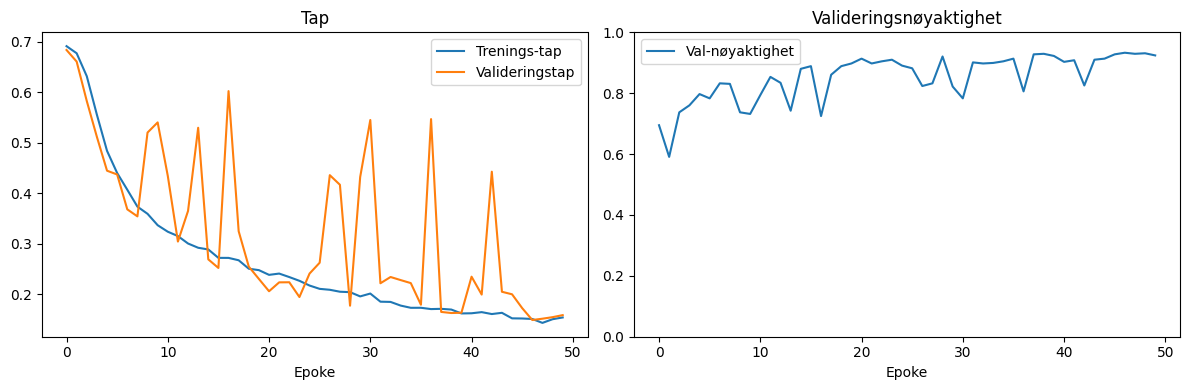

              precision    recall  f1-score   support

        fast       0.90      0.96      0.93       708
         løs       0.96      0.89      0.92       708

    accuracy                           0.93      1416
   macro avg       0.93      0.93      0.93      1416
weighted avg       0.93      0.93      0.93      1416

Forvirringsmatrise:
[[681  27]
 [ 79 629]]


In [37]:
# ============================================================
# Celle 8: Visualisering av treningsforløp og evaluering på testdata
#
# Venstre plot:  trenings- og valideringstap per epoke
# Høyre plot:    valideringsnøyaktighet per epoke
#
# Deretter kjøres modellen på testsettet og resultatene vises som:
#   - Klassifikasjonsrapport (presisjon, recall, F1)
#   - Forvirringsmatrise
# ============================================================

# Plot treningsforløp
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label="Trenings-tap")
ax1.plot(val_losses, label="Valideringstap")
ax1.set_title("Tap")
ax1.set_xlabel("Epoke")
ax1.legend()

ax2.plot(val_accuracies, label="Val-nøyaktighet")
ax2.set_title("Valideringsnøyaktighet")
ax2.set_xlabel("Epoke")
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()

# Forvirringsmatrise og klassifikasjonsrapport på testsettet
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds, target_names=["fast", "løs"]))
print("Forvirringsmatrise:")
print(confusion_matrix(all_labels, all_preds))

In [38]:
# ============================================================
# Celle 9: Aksebidragsanalyse – nullstille én akse om gangen
#
# Tester hvor viktig hver akselerometer-akse (X, Y, Z) er for
# klassifikasjonen ved å sette én akse til null og måle
# nøyaktigheten. Stor nedgang → aksen er viktig.
# ============================================================
def test_with_axis_zeroed(axis_idx, name):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.clone()
            X_batch[:, axis_idx, :] = 0  # nullstill denne aksen
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch).argmax(1)
            correct += (preds == y_batch).sum().item()
            total += len(y_batch)
    print(f"Nøyaktighet uten {name}-akse: {correct/total:.4f}")

# Kjør analyse for alle tre aksene
test_with_axis_zeroed(0, "X")
test_with_axis_zeroed(1, "Y")
test_with_axis_zeroed(2, "Z")

Nøyaktighet uten X-akse: 0.5657
Nøyaktighet uten Y-akse: 0.5374
Nøyaktighet uten Z-akse: 0.6102


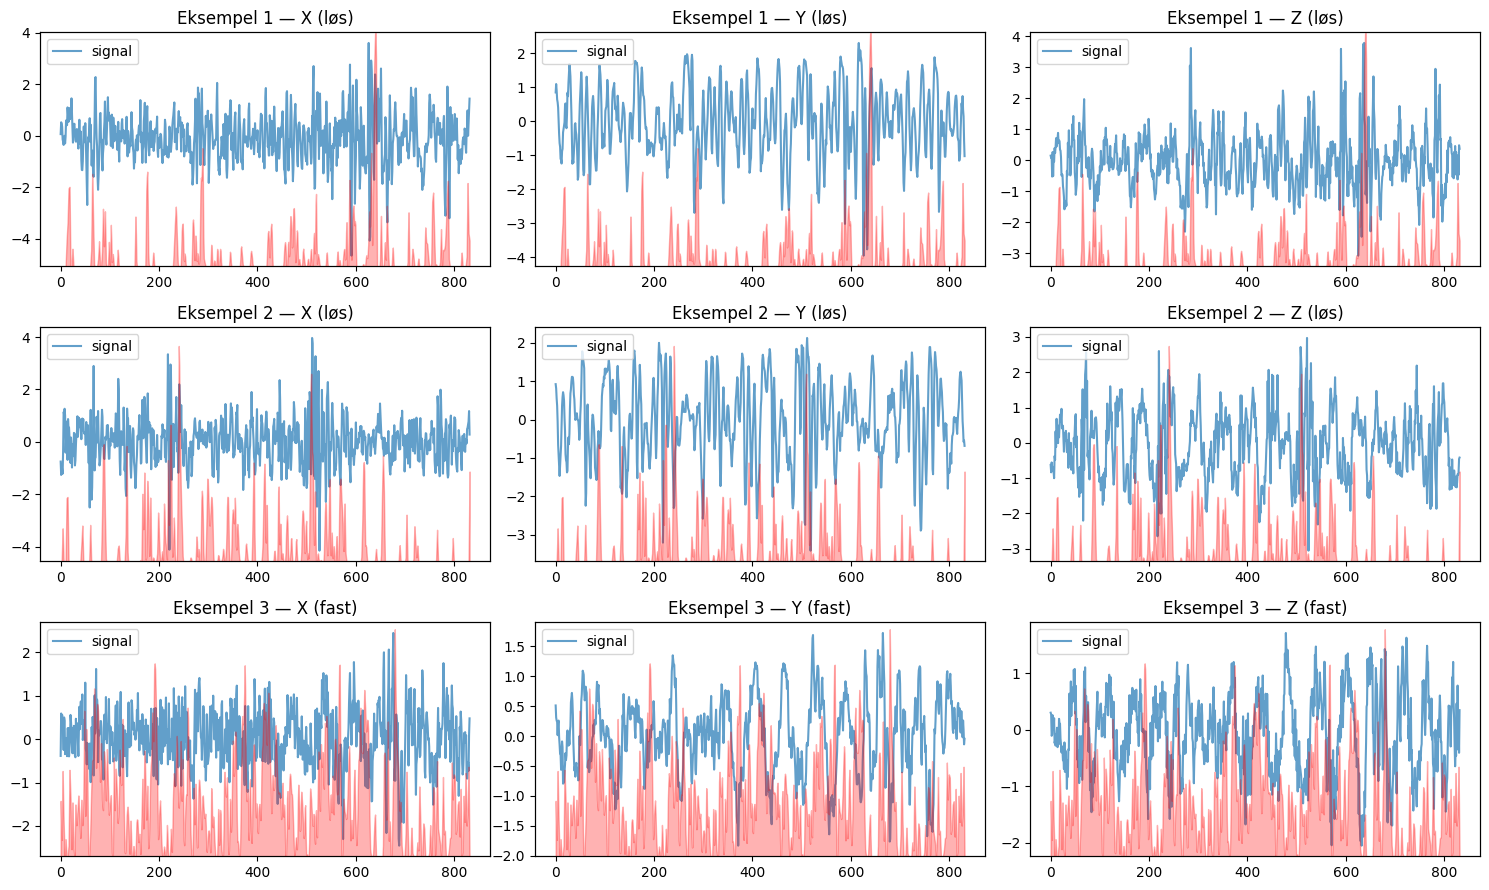

In [39]:
# ============================================================
# Celle 10: GradCAM-visualisering
#
# GradCAM (Gradient-weighted Class Activation Mapping) viser
# hvilke deler av tidssignalet modellen fokuserer på når den
# klassifiserer et vindu som fast eller løst.
#
# For hvert testeksempel vises signal (blå) og oppmerksomhet
# (rød) for alle tre aksene (X, Y, Z).
# ============================================================
def plot_gradcam(dataset, num_samples=3):
    model.eval()
    activations, gradients = {}, {}

    # Hooks registrerer aktiveringer og gradienter fra siste konvlag
    def forward_hook(m, inp, out):
        activations["value"] = out.detach()
    def backward_hook(m, grad_in, grad_out):
        gradients["value"] = grad_out[0].detach()

    # Koble hooks til siste konvolusjonslag (Blokk 3)
    handle_f = model.features[6].register_forward_hook(forward_hook)
    handle_b = model.features[6].register_full_backward_hook(backward_hook)

    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples * 3))

    for i in range(num_samples):
        X_sample, y_sample = dataset[i]
        X_sample = X_sample.unsqueeze(0).to(device)
        X_sample.requires_grad_(True)

        output = model(X_sample)
        pred = output.argmax(1).item()
        model.zero_grad()
        output[0, pred].backward()

        # Beregn GradCAM-vekter: gjennomsnitt av gradienter over tid
        weights = gradients["value"].mean(dim=2, keepdim=True)  # (1, C, 1)
        cam = (weights * activations["value"]).sum(dim=1).squeeze()  # (L,)
        cam = torch.relu(cam).cpu().numpy()
        cam = cam / (cam.max() + 1e-8)  # normaliser til 0–1

        # Skaler GradCAM-kartet opp til signallengde (832 tidspunkter)
        cam_upsampled = np.interp(
            np.linspace(0, len(cam)-1, 832),
            np.arange(len(cam)), cam
        )

        signal = X_sample.detach().cpu().squeeze().numpy()  # (3, 832)
        label = 'løs' if pred == 1 else 'fast'

        for j, axis_name in enumerate(["X", "Y", "Z"]):
            ax = axes[i, j]
            ax.plot(signal[j], label="signal", alpha=0.7)
            ax2 = ax.twinx()
            ax2.fill_between(range(832), cam_upsampled,
                           alpha=0.3, color="red", label="oppmerksomhet")
            ax2.set_ylim(0, 1)
            ax2.set_yticks([])
            ax.set_title(f"Eksempel {i+1} — {axis_name} ({label})")
            ax.legend(loc="upper left")

    handle_f.remove()
    handle_b.remove()
    plt.tight_layout()
    plt.show()

plot_gradcam(test_dataset)

In [40]:
# ============================================================
# Celle 11: Inferens på nye data (biltur-mappe)
#
# Laster den beste trente modellen og normaliseringsparametrene,
# leser CSV-filer fra en angitt mappe, deler dem inn i vinduer,
# normaliserer og kjører prediksjon.
#
# Resultatet viser hvor mange vinduer som klassifiseres som
# fast vs. løs, og gir en samlet vurdering.
# ============================================================
import os

# Last inn modell
model = CNN1D()
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

# Last inn normaliseringsparametre fra trening
mean = np.load("mean.npy")
std  = np.load("std.npy")

window_size = 832
step = 416
all_windows = []

# Les alle CSV-filer i biltur-mappen
folder = r"data_bach-main\data_bach-main\iio_ferdig\biltur\134210"
files = [f for f in os.listdir(folder) if f.endswith(".csv")]
print(f"Fant {len(files)} CSV-filer")

for fname in files:
    df = pd.read_csv(os.path.join(folder, fname))
    data = df[["x", "y", "z"]].values.astype(np.float32)
    for start in range(0, len(data) - window_size, step):
        all_windows.append(data[start:start + window_size])

X_new = np.array(all_windows)
print(f"Totalt antall vinduer: {len(X_new)}")

# Normaliser med treningssettets parametre
X_new = (X_new - mean) / std

# Konverter til tensor
X_tensor = torch.tensor(X_new.transpose(0, 2, 1), dtype=torch.float32)

# Kjør prediksjon
with torch.no_grad():
    logits = model(X_tensor)
    probs  = torch.softmax(logits, dim=1)
    preds  = logits.argmax(dim=1)

fast_count = (preds == 0).sum().item()
løs_count  = (preds == 1).sum().item()
total = len(preds)

print(f"\nFaste vinduer:  {fast_count} ({fast_count/total:.1%})")
print(f"Løse vinduer:   {løs_count} ({løs_count/total:.1%})")

overall = "FAST" if fast_count > løs_count else "LØS"
print(f"\n>>> Samlet vurdering: {overall} <<<")


Fant 38 CSV-filer
Totalt antall vinduer: 4366

Faste vinduer:  354 (8.1%)
Løse vinduer:   4012 (91.9%)

>>> Samlet vurdering: LØS <<<
